# Simulacion Mundial 2026
Monte Carlo (10,000 iteraciones) desde el estado actual del torneo.
Datos actualizados al **23 de junio 2026** — 44 partidos jugados, 28 pendientes.

In [1]:
import sys, json, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.models.poisson_model import PoissonModel, WC_GOAL_SCALE
from src.simulation.tournament import (
    GROUPS, compute_standings, run_monte_carlo, NAME_ALIASES
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

with open('../models/poisson_params.json') as f:
    poisson_params = json.load(f)
with open('../models/elo_ratings.json') as f:
    elo_ratings = json.load(f)

poisson = PoissonModel()
poisson.params_ = poisson_params
poisson.teams_  = list(poisson_params['attack'].keys())

print('Poisson model loaded:', len(poisson.teams_), 'teams')
print('ELO ratings loaded:  ', len(elo_ratings), 'teams')

Poisson model loaded: 319 teams
ELO ratings loaded:   324 teams


## 1. Estado actual — Clasificaciones de grupo

In [2]:
df_raw = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])
wc26   = df_raw[(df_raw['tournament'] == 'FIFA World Cup') & (df_raw['date'].dt.year == 2026)].copy()
played = wc26.dropna(subset=['home_score', 'away_score']).copy()
pending = wc26[wc26['home_score'].isna()].copy()

print(f'Partidos jugados : {len(played)}')
print(f'Partidos pendientes: {len(pending)}')
print()

for group, teams in sorted(GROUPS.items()):
    group_played = played[played['home_team'].isin(teams) & played['away_team'].isin(teams)]
    st = compute_standings(group_played, teams)
    pts_str = '  '.join(f"{r['team'][:12]:12s} {int(r['pts'])}pts {int(r['gd']):+d}" for _, r in st.iterrows())
    print(f'Grupo {group}: {pts_str}')

Partidos jugados : 44
Partidos pendientes: 28

Grupo A: Argentina    6pts +5  Austria      3pts +0  Algeria      3pts -2  Jordan       0pts -3
Grupo B: United State 6pts +5  Australia    3pts +0  Paraguay     3pts -2  Turkey       0pts -3
Grupo C: Egypt        4pts +2  Iran         2pts +0  Belgium      2pts +0  New Zealand  1pts -2


Grupo D: Canada       4pts +6  Switzerland  4pts +3  Bosnia and H 1pts -3  Qatar        1pts -6
Grupo E: Brazil       4pts +3  Morocco      4pts +1  Scotland     3pts +0  Haiti        0pts -4
Grupo F: Spain        4pts +4  Uruguay      2pts +0  Cape Verde   2pts +0  Saudi Arabia 1pts -4
Grupo G: Colombia     3pts +2  Portugal     1pts +0  DR Congo     1pts +0  Uzbekistan   0pts -2


Grupo H: England      3pts +2  Ghana        3pts +1  Panama       0pts -1  Croatia      0pts -2
Grupo I: Germany      6pts +7  Ivory Coast  3pts +0  Ecuador      1pts -1  Curaçao      1pts -6
Grupo J: Mexico       6pts +3  South Korea  3pts +0  Czech Republ 1pts -1  South Africa 1pts -2
Grupo K: France       6pts +5  Norway       6pts +4  Senegal      0pts -3  Iraq         0pts -6
Grupo L: Netherlands  4pts +4  Japan        4pts +4  Sweden       3pts +0  Tunisia      0pts -8


## 2. Monte Carlo — 10,000 simulaciones

In [3]:
mc = run_monte_carlo(
    '../data/raw/results.csv',
    poisson_model=poisson, 
    elo_ratings=elo_ratings,
    n_simulations=10_000,
    seed=42,
)
print('\nDone.')

  Played:  44 matches
  Pending: 28 matches
  Warming matrix cache...
  Cache size: 28 matrices


  2000/10000...


  4000/10000...


  6000/10000...


  8000/10000...


  10000/10000...

Done.


## 3. Probabilidad de ganar el torneo — Top 20

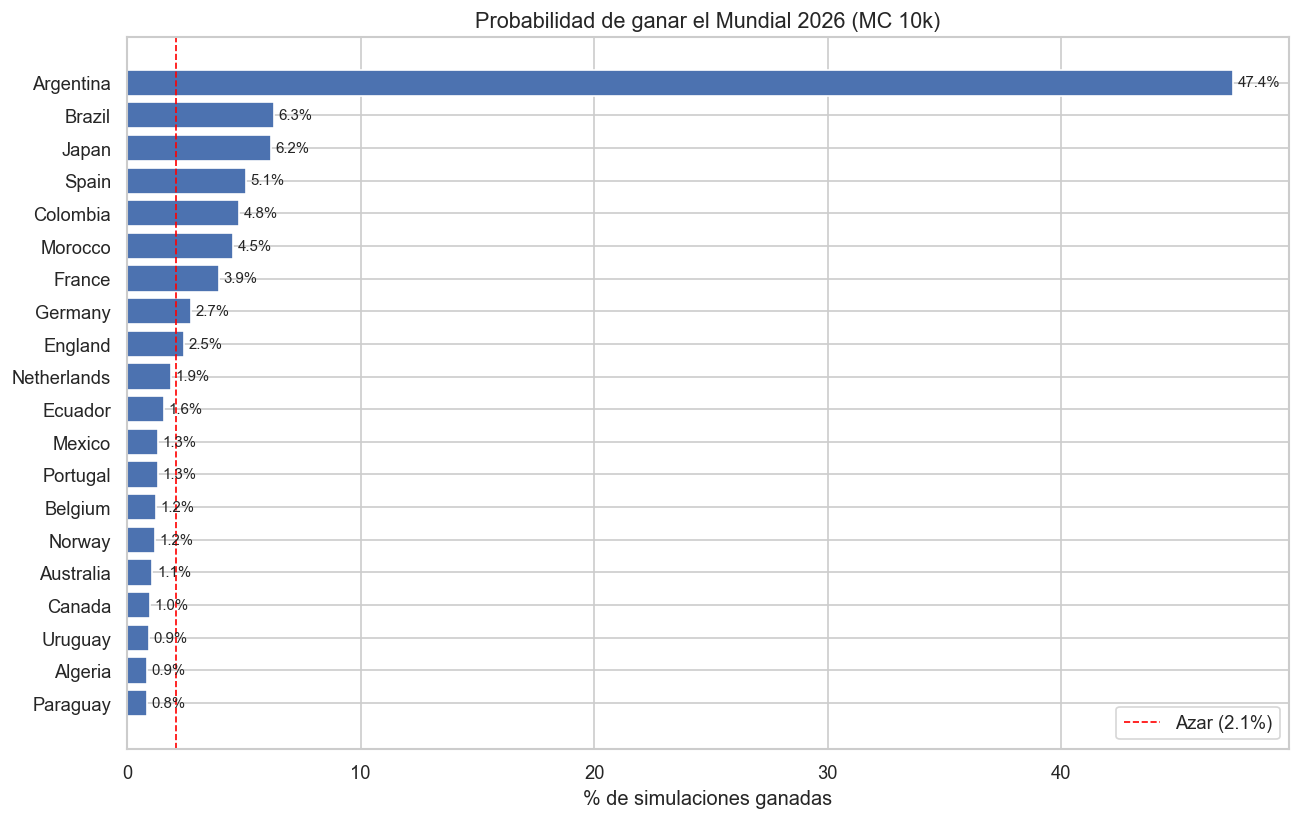

In [4]:
top20 = mc.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['team'][::-1], top20['p_winner'][::-1] * 100, color='#4c72b0')
for bar, v in zip(bars, top20['p_winner'][::-1] * 100):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.set_title('Probabilidad de ganar el Mundial 2026 (MC 10k)', fontsize=13)
ax.set_xlabel('% de simulaciones ganadas')
ax.axvline(100/48, color='red', ls='--', lw=1, label=f'Azar ({100/48:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Probabilidad por etapa — Top 16

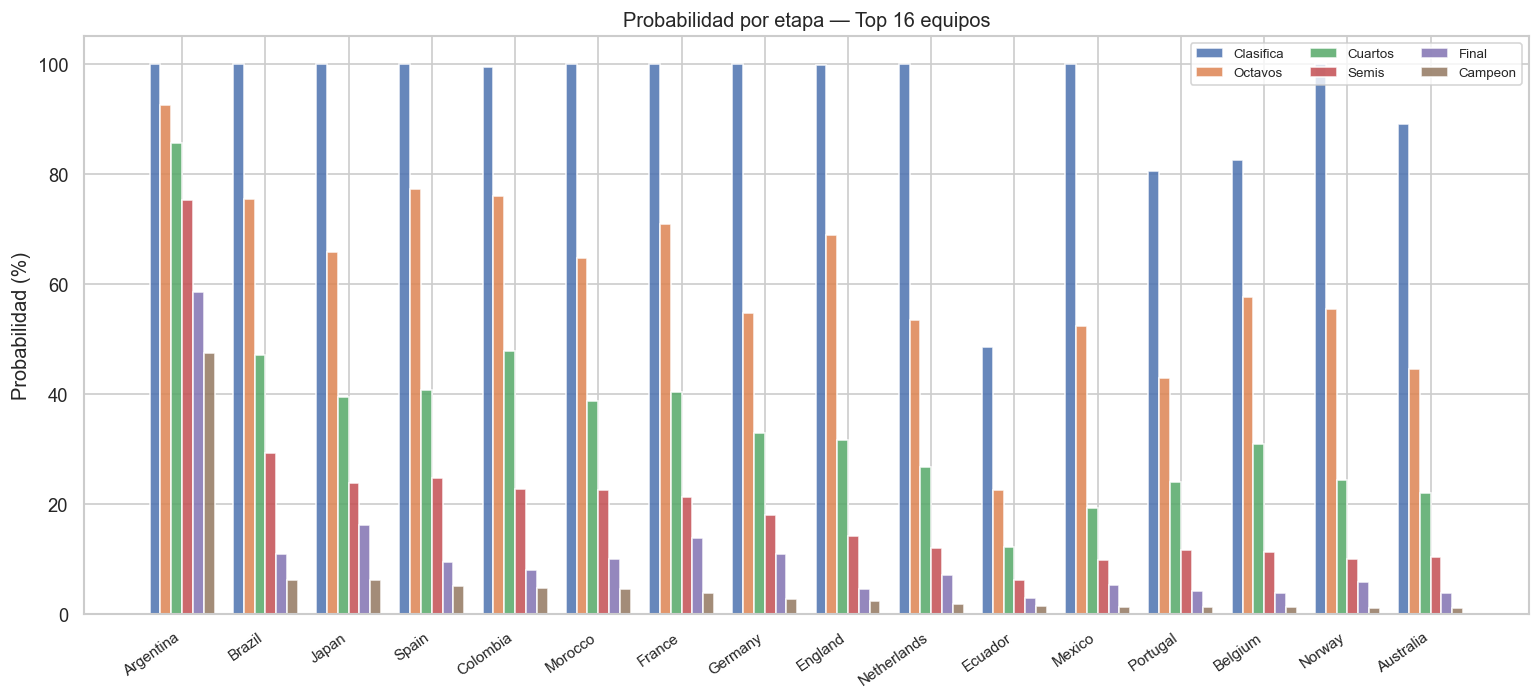

In [5]:
top16 = mc.head(16).copy()
stages = ['p_qualify', 'p_r16', 'p_qf', 'p_sf', 'p_final', 'p_winner']
stage_labels = ['Clasifica', 'Octavos', 'Cuartos', 'Semis', 'Final', 'Campeon']

plot_df = top16.set_index('team')[stages].copy()
plot_df.columns = stage_labels

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(top16))
width = 0.13
colors = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2','#937860']

for i, (stage, label, color) in enumerate(zip(stages, stage_labels, colors)):
    ax.bar(x + i * width, top16[stage] * 100, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(top16['team'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Probabilidad (%)')
ax.set_title('Probabilidad por etapa — Top 16 equipos')
ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Probabilidad de clasificar — heatmap por grupo

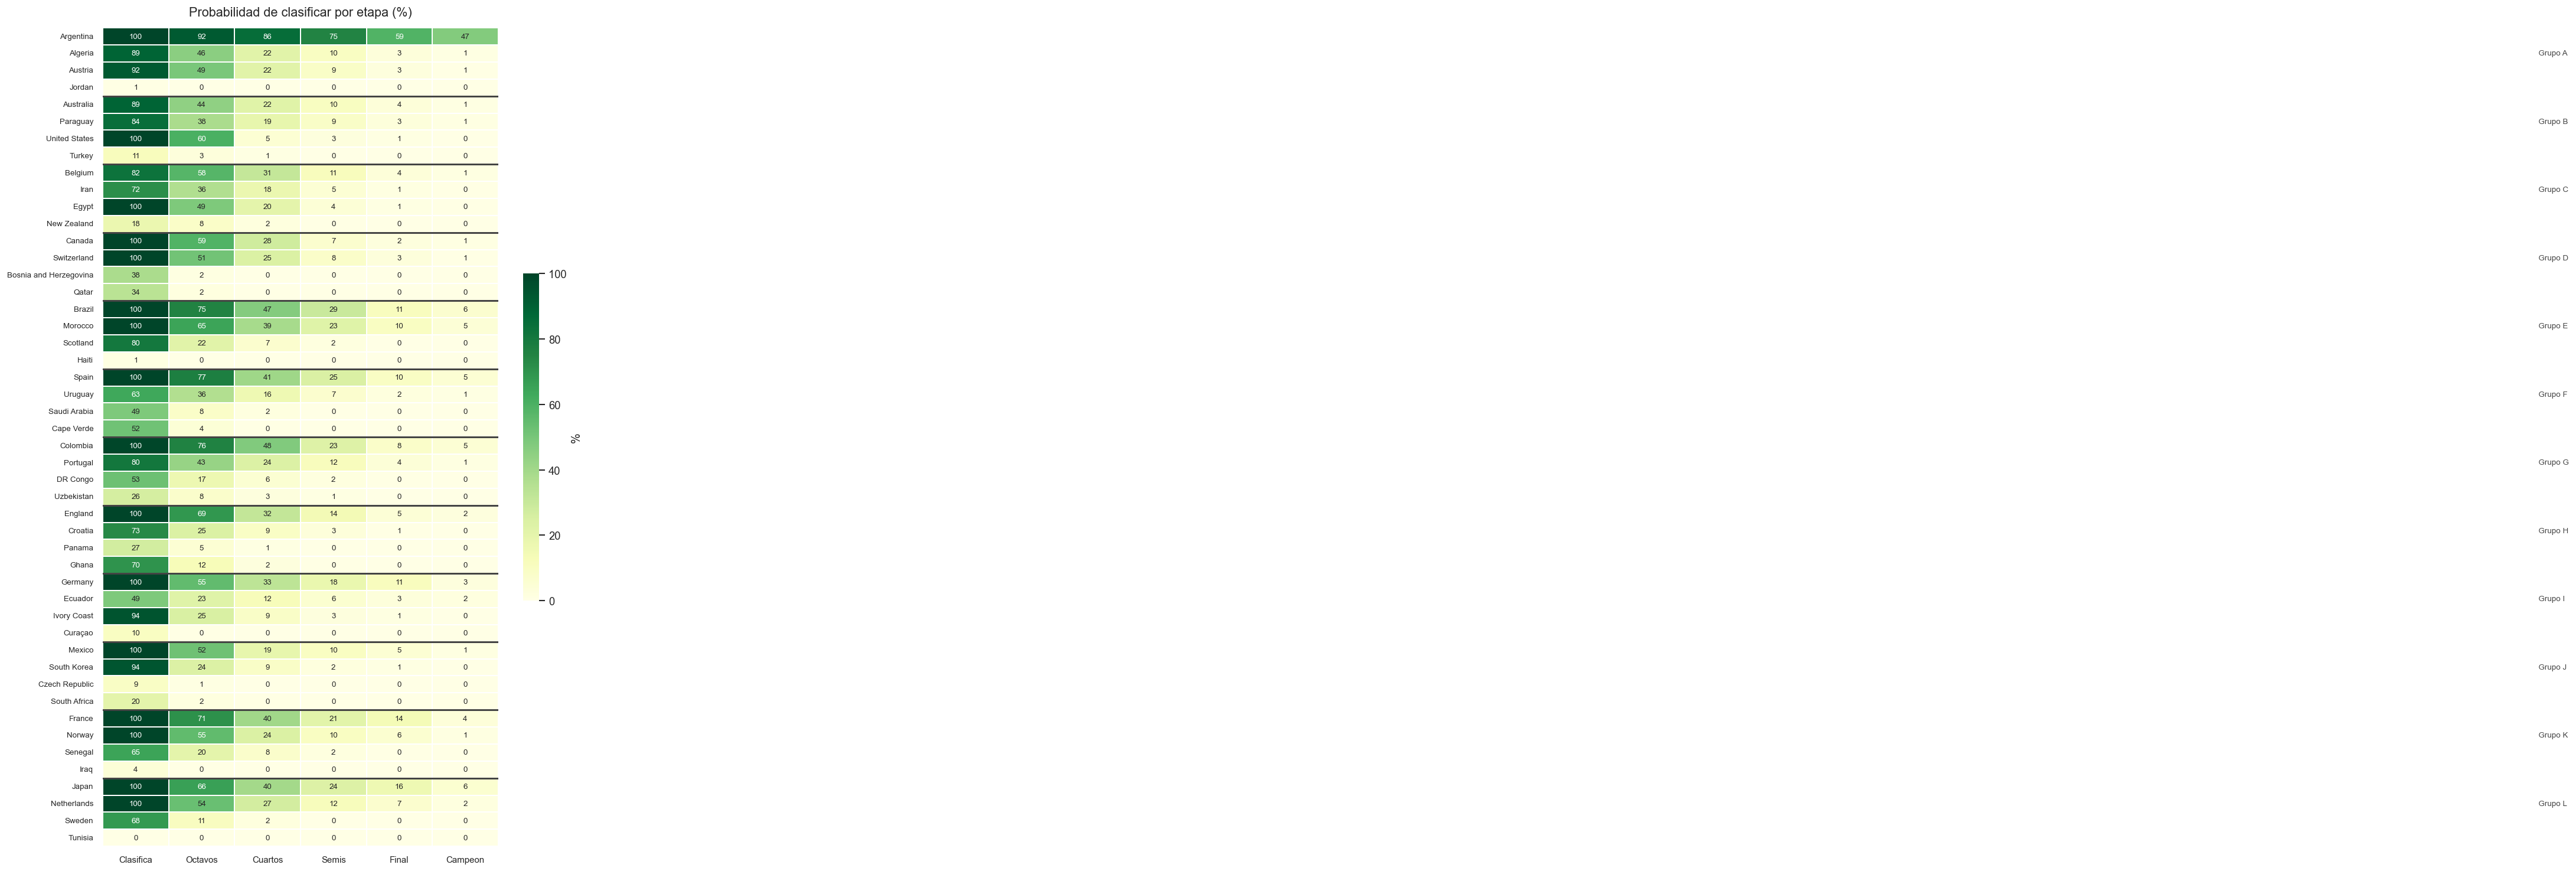

In [6]:
stages      = ['p_qualify', 'p_r16', 'p_qf', 'p_sf', 'p_final', 'p_winner']
stage_lbls  = ['Clasifica', 'Octavos', 'Cuartos', 'Semis', 'Final', 'Campeon']

# Sort: group A→L, within each group by p_winner desc
mc_sorted = (
    mc.sort_values(['group', 'p_winner'], ascending=[True, False])
    .reset_index(drop=True)
)

matrix = (mc_sorted[stages].values * 100).round(1)

# Group boundary rows (where a new group starts)
boundaries = mc_sorted.groupby('group', sort=False).size().cumsum().values[:-1]

fig, ax = plt.subplots(figsize=(9, 15))
sns.heatmap(
    matrix,
    ax=ax,
    xticklabels=stage_lbls,
    yticklabels=mc_sorted['team'].tolist(),
    cmap='YlGn', vmin=0, vmax=100,
    annot=True, fmt='.0f', annot_kws={'size': 8},
    linewidths=0.2, linecolor='white',
    cbar_kws={'label': '%', 'shrink': 0.4},
)

# Separator lines between groups
for b in boundaries:
    ax.axhline(b, color='#444', lw=1.8)

# Group labels on the right
group_sizes = mc_sorted.groupby('group', sort=False).size()
start = 0
for grp, size in group_sizes.items():
    mid = start + size / 2 - 0.5
    ax.text(len(stages) + 0.15, mid, f'  Grupo {grp}',
            va='center', fontsize=8, color='#444',
            transform=ax.get_yaxis_transform())
    start += size

ax.set_title('Probabilidad de clasificar por etapa (%)', fontsize=13, pad=12)
ax.yaxis.set_tick_params(labelsize=8)
ax.xaxis.set_tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## 6. Proyeccion grupo a grupo — clasificacion mas probable

In [7]:
df_raw2  = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])
wc26b    = df_raw2[(df_raw2['tournament']=='FIFA World Cup') & (df_raw2['date'].dt.year==2026)].copy()
played2  = wc26b.dropna(subset=['home_score','away_score']).copy()
pending2 = wc26b[wc26b['home_score'].isna()].copy()

extra = []
for _, row in pending2.iterrows():
    h, a = row['home_team'], row['away_team']
    hg, ag = poisson.predict_exact_score(
        NAME_ALIASES.get(h, h), NAME_ALIASES.get(a, a), neutral=True, goal_scale=WC_GOAL_SCALE
    )
    extra.append({'home_team': h, 'away_team': a, 'home_score': hg, 'away_score': ag})

all_res = pd.concat([
    played2[['home_team','away_team','home_score','away_score']],
    pd.DataFrame(extra)
], ignore_index=True)

print('Clasificacion proyectada (score mas probable para partidos pendientes)\n')
for group, teams in sorted(GROUPS.items()):
    gm = all_res[all_res['home_team'].isin(teams) & all_res['away_team'].isin(teams)]
    st = compute_standings(gm, teams)
    print(f'Grupo {group}:')
    for rank, (_, row) in enumerate(st.iterrows(), 1):
        arrow = '->' if rank <= 2 else '  '
        print(f'  {arrow} {rank}. {row["team"]:26s} {int(row["pts"]):2d}pts  {int(row["gd"]):+3d}gd')
    print()

Clasificacion proyectada (score mas probable para partidos pendientes)

Grupo A:
  -> 1. Argentina                   9pts   +8gd
  -> 2. Algeria                     6pts   -1gd
     3. Austria                     3pts   -1gd
     4. Jordan                      0pts   -6gd

Grupo B:
  -> 1. United States               7pts   +5gd
  -> 2. Australia                   4pts   +0gd
     3. Paraguay                    4pts   -2gd
     4. Turkey                      1pts   -3gd

Grupo C:
  -> 1. Egypt                       5pts   +2gd
  -> 2. Belgium                     5pts   +1gd
     3. Iran                        3pts   +0gd
     4. New Zealand                 1pts   -3gd

Grupo D:
  -> 1. Canada                      5pts   +6gd
  -> 2. Switzerland                 5pts   +3gd
     3. Bosnia and Herzegovina      4pts   -2gd
     4. Qatar                       1pts   -7gd

Grupo E:
  -> 1. Brazil                      7pts   +4gd
  -> 2. Morocco                     7pts   +3gd
     3. Scotlan

## 7. Semifinalistas y finalistas mas probables

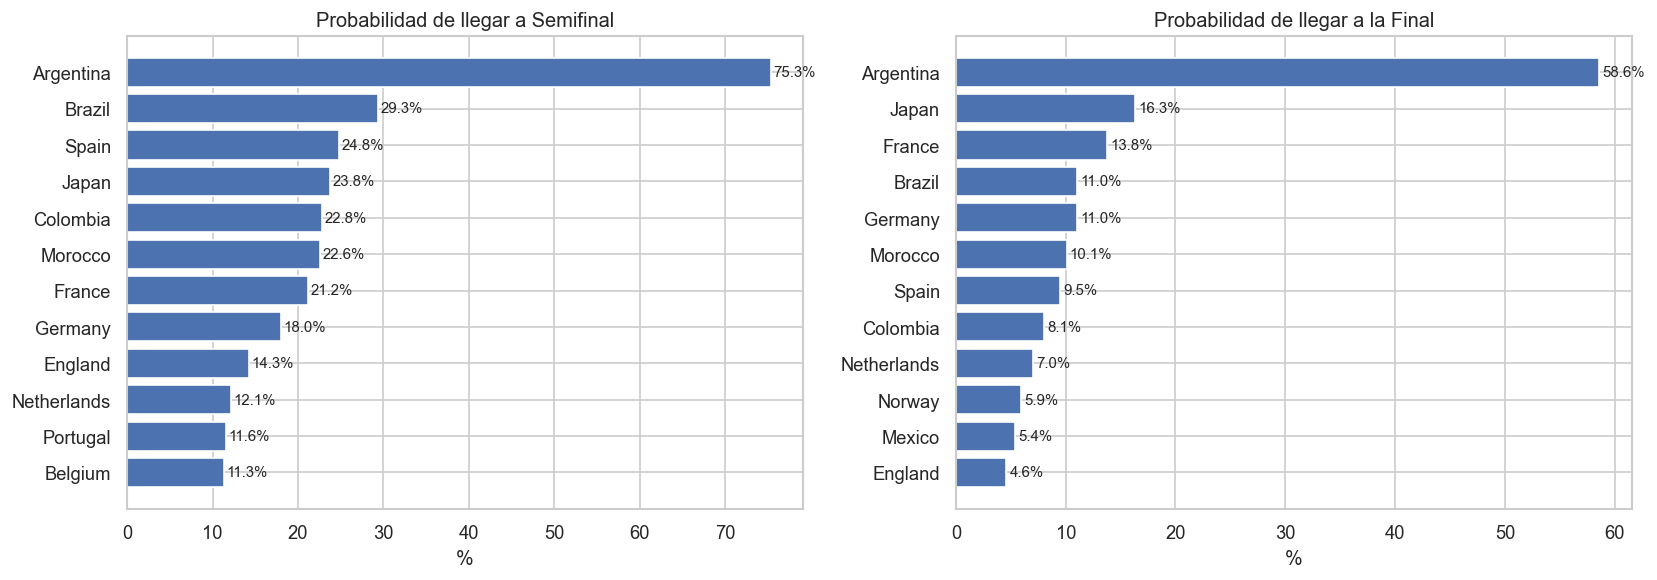

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stage, title in [
    (axes[0], 'p_sf',    'Probabilidad de llegar a Semifinal'),
    (axes[1], 'p_final', 'Probabilidad de llegar a la Final'),
]:
    top = mc.nlargest(12, stage)
    bars = ax.barh(top['team'][::-1], top[stage][::-1] * 100, color='#4c72b0')
    for bar, v in zip(bars, top[stage][::-1] * 100):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('%')

plt.tight_layout()
plt.show()

## 8. Tabla completa de probabilidades

In [9]:
prob_cols = ['p_qualify','p_r16','p_qf','p_sf','p_final','p_winner']
col_lbls  = ['Clasifica','Octavos','Cuartos','Semis','Final','Campeon']

tbl = mc[['team','group'] + prob_cols].copy()
tbl.columns = ['Equipo','Grupo'] + col_lbls

cmap = sns.light_palette('#2ecc71', as_cmap=True)

display(
    tbl.style
    .background_gradient(cmap=cmap, subset=col_lbls, vmin=0, vmax=1)
    .format({c: '{:.1%}' for c in col_lbls})
    .set_properties(**{'font-size': '11px', 'text-align': 'center'})
    .set_properties(subset=['Equipo','Grupo'], **{'text-align': 'left'})
    .hide(axis='index')
)

Equipo,Grupo,Clasifica,Octavos,Cuartos,Semis,Final,Campeon
Argentina,A,100.0%,92.5%,85.5%,75.3%,58.6%,47.4%
Brazil,E,100.0%,75.4%,47.1%,29.3%,11.0%,6.3%
Japan,L,100.0%,65.9%,39.5%,23.8%,16.3%,6.2%
Spain,F,100.0%,77.2%,40.7%,24.8%,9.5%,5.1%
Colombia,G,99.5%,75.9%,47.8%,22.8%,8.1%,4.8%
Morocco,E,100.0%,64.7%,38.7%,22.6%,10.1%,4.5%
France,K,100.0%,70.9%,40.4%,21.2%,13.8%,3.9%
Germany,I,100.0%,54.8%,32.9%,18.0%,11.0%,2.7%
England,H,99.9%,68.8%,31.6%,14.3%,4.6%,2.5%
Netherlands,L,100.0%,53.5%,26.7%,12.1%,7.0%,1.9%
